<a href="https://colab.research.google.com/github/samritha07/Deep-Learning/blob/main/DL_EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
Libraries imported successfully!
Please upload your Cats vs Dogs dataset ZIP file.


Saving archive (25).zip to archive (25).zip

Uploaded file: archive (25).zip
Dataset extracted successfully!
Extraction path: /content/cats_dogs_dataset

Dataset folder structure:
cats_dogs_dataset/
    dataset/
        training_set/
            cats/
                cat.2045.jpg
                cat.1009.jpg
                cat.906.jpg
                cat.2394.jpg
                cat.91.jpg
            dogs/
                dog.390.jpg
                dog.3510.jpg
                dog.2451.jpg
                dog.484.jpg
                dog.1298.jpg
        test_set/
            cats/
                cat.4100.jpg
                cat.4291.jpg
                cat.4092.jpg
                cat.4791.jpg
                cat.4456.jpg
            dogs/
                dog.4707.jpg
                dog.4578.jpg
                dog.4125.jpg
                dog.4745.jpg
                dog.4382.jpg

Cat folder: /content/cats_dogs_dataset/dataset/test_set/cats
Dog folder: /content/cats_dogs_dataset/

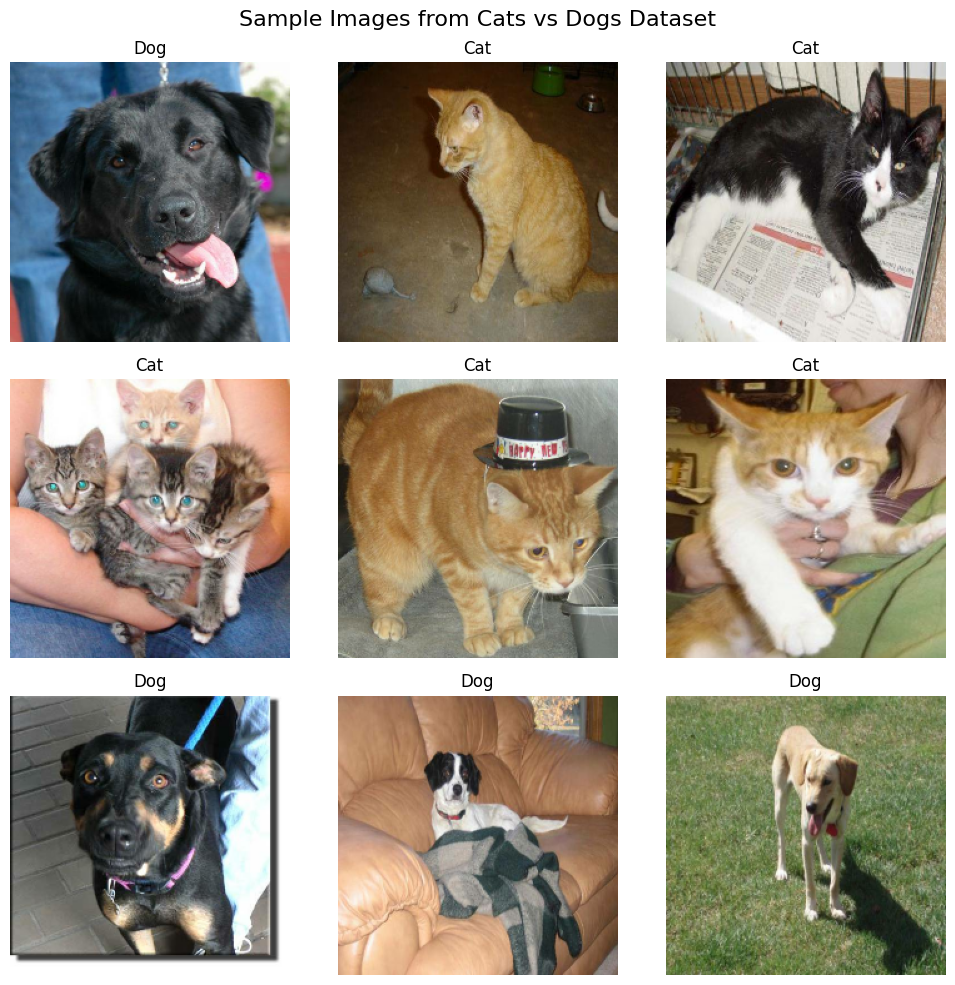


TASK A COMPLETED SUCCESSFULLY
Student Roll No : 24BAD103
Dataset         : Cats vs Dogs
Classes         : ['Cat', 'Dog']
Image Size      : (224, 224)
Batch Size      : 32
Train Split     : 70%
Validation Split: 15%
Test Split      : 15%


In [4]:
# EXPERIMENT 4
# TRANSFER LEARNING USING PRE-TRAINED VISION MODELS
# FOR IMAGE RECOGNITION
# TASK A: DATASET PREPARATION
# Student Roll No: 24BAD103
# Dataset: Cats vs Dogs
# Import Required Libraries

import os
import zipfile
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import files

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")


# Upload Cats vs Dogs ZIP Dataset

print("Please upload your Cats vs Dogs dataset ZIP file.")

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("\nUploaded file:", zip_file)


# Extract the ZIP Dataset

extract_path = "/content/cats_dogs_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Extraction path:", extract_path)


# Display Dataset Folder Structure

print("\nDataset folder structure:")

for root, dirs, files_list in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(indent + os.path.basename(root) + '/')

    subindent = ' ' * 4 * (level + 1)

    for file in files_list[:5]:
        print(subindent + file)

    if level >= 2:
        continue


# Automatically Find Cat and Dog Folders

cat_folder = None
dog_folder = None

for root, dirs, files_list in os.walk(extract_path):

    folder_name = os.path.basename(root).lower()

    if folder_name == "cats" or folder_name == "cat":
        cat_folder = root

    if folder_name == "dogs" or folder_name == "dog":
        dog_folder = root

print("\nCat folder:", cat_folder)
print("Dog folder:", dog_folder)


# Create a Clean Dataset Folder

dataset_path = "/content/final_dataset"

if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)

os.makedirs(dataset_path)
os.makedirs(os.path.join(dataset_path, "Cat"))
os.makedirs(os.path.join(dataset_path, "Dog"))

print("\nClean dataset folders created.")


# Copy Images into Cat and Dog Folders

def copy_images(source_folder, destination_folder):

    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    count = 0

    if source_folder is not None:

        for file_name in os.listdir(source_folder):

            if file_name.lower().endswith(valid_extensions):

                source = os.path.join(source_folder, file_name)
                destination = os.path.join(destination_folder, file_name)

                try:
                    shutil.copy2(source, destination)
                    count += 1
                except:
                    pass

    return count


cat_count = copy_images(
    cat_folder,
    os.path.join(dataset_path, "Cat")
)

dog_count = copy_images(
    dog_folder,
    os.path.join(dataset_path, "Dog")
)

print("\nNumber of Cat images:", cat_count)
print("Number of Dog images:", dog_count)


# Check Dataset

if cat_count == 0 or dog_count == 0:

    print("\nWARNING!")
    print("Cat/Dog folders were not detected correctly.")
    print("Please check the folder structure printed above.")

else:

    print("\nDataset loaded successfully!")
    print("Total images:", cat_count + dog_count)


# Set Image Parameters

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("\nImage size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)


# Load Images from Directory

dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    labels="inferred",

    label_mode="int",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)

class_names = dataset.class_names

print("\nClasses detected:")
print(class_names)


# Calculate Dataset Size

dataset_size = tf.data.experimental.cardinality(dataset).numpy()

print("\nTotal number of batches:", dataset_size)


# Split Dataset

train_size = int(0.70 * dataset_size)

validation_size = int(0.15 * dataset_size)

train_ds = dataset.take(train_size)

remaining_ds = dataset.skip(train_size)

val_ds = remaining_ds.take(validation_size)

test_ds = remaining_ds.skip(validation_size)

print("\nDataset Split")
print("--------------------------------")

print(
    "Training batches   :",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches :",
    tf.data.experimental.cardinality(val_ds).numpy()
)

print(
    "Testing batches    :",
    tf.data.experimental.cardinality(test_ds).numpy()
)


# Normalize / Preprocess Images

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda images, labels:
    (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda images, labels:
    (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda images, labels:
    (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)


# Optimize Dataset Loading

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("\nImage normalization and preprocessing completed.")


# Display Sample Images

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.suptitle(
    "Sample Images from Cats vs Dogs Dataset",
    fontsize=16
)

plt.tight_layout()

plt.show()


# Display Final Dataset Information

print("\nTASK A COMPLETED SUCCESSFULLY")

print("Student Roll No : 24BAD103")
print("Dataset         : Cats vs Dogs")
print("Classes         :", class_names)
print("Image Size      :", IMG_SIZE)
print("Batch Size      :", BATCH_SIZE)
print("Train Split     : 70%")
print("Validation Split: 15%")
print("Test Split      : 15%")

In [5]:
# TASK B: IMPLEMENTING TRANSFER LEARNING
# Student Roll No: 24BAD103
# Model: ResNet-50

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pre-trained ResNet-50 model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully!")


# Freeze the feature extraction layers

base_model.trainable = False

print("Feature extraction layers frozen.")


# Add new classification layers

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(2, activation="softmax")(x)


# Create the final transfer learning model

model = Model(
    inputs=base_model.input,
    outputs=output
)


# Display model summary

model.summary()


# Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel compiled successfully!")

print("\nTASK B COMPLETED SUCCESSFULLY")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet-50 loaded successfully!
Feature extraction layers frozen.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Model compiled successfully!

TASK B COMPLETED SUCCESSFULLY


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 365s 8s/step - accuracy: 0.5206 - loss: 0.8014 - val_accuracy: 0.5590 - val_loss: 0.6861
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 347s 8s/step - accuracy: 0.5085 - loss: 0.7649 - val_accuracy: 0.5417 - val_loss: 0.6887
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 342s 8s/step - accuracy: 0.5376 - loss: 0.7118 - val_accuracy: 0.5521 - val_loss: 0.6851
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 340s 8s/step - accuracy: 0.5518 - loss: 0.6981 - val_accuracy: 0.5382 - val_loss: 0.6865
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 325s 7s/step - accuracy: 0.5433 - loss: 0.6911 - val_accuracy: 0.5104 - val_loss: 0.6981

Model training completed successfully!

Training Results
--------------------------------
Epoch 1: Training Accuracy = 0.5206, Validation Accuracy = 0.5590, Training Loss = 0.8014, Validation Loss = 0.6861
Epoch 2: Training Accuracy = 0.5085, Validation Accuracy = 0.5417, Training Loss = 0.7649, Validation Loss = 0.6887
Epoch 3: Training Accuracy = 0.5376, Validation

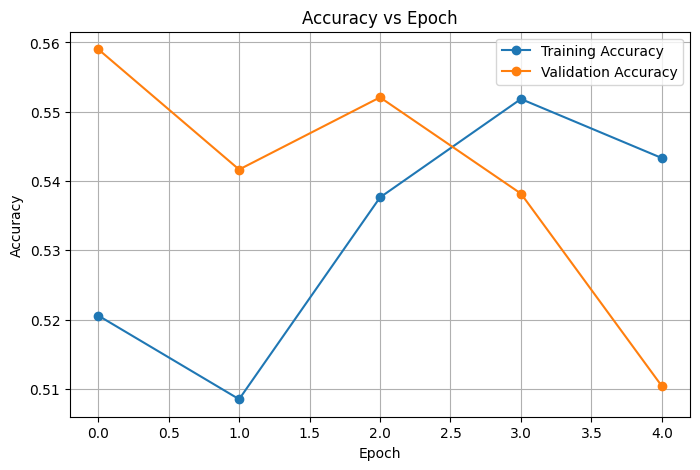

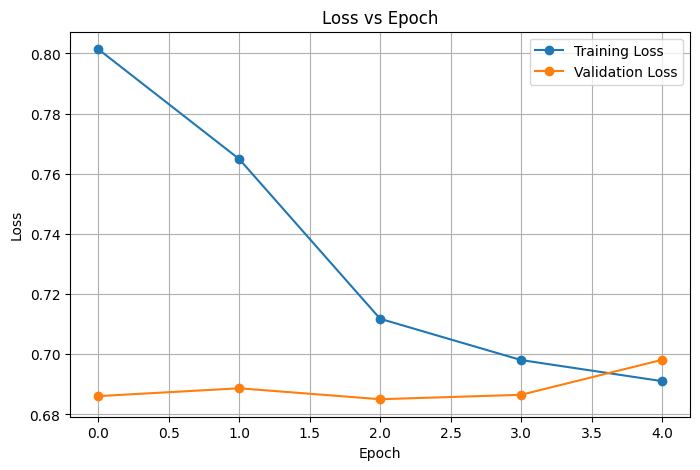


TASK C COMPLETED SUCCESSFULLY
Student Roll No : 24BAD103
Number of Epochs: 5
Final Training Accuracy: 54.33 %
Final Validation Accuracy: 51.04 %
Test Accuracy: 53.62 %


In [6]:
# TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION
# Student Roll No: 24BAD103

import matplotlib.pyplot as plt
import numpy as np

# Train the transfer learning model

EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("\nModel training completed successfully!")


# Display Training and Validation Results

print("\nTraining Results")
print("--------------------------------")

for epoch in range(EPOCHS):
    print(
        f"Epoch {epoch + 1}: "
        f"Training Accuracy = {history.history['accuracy'][epoch]:.4f}, "
        f"Validation Accuracy = {history.history['val_accuracy'][epoch]:.4f}, "
        f"Training Loss = {history.history['loss'][epoch]:.4f}, "
        f"Validation Loss = {history.history['val_loss'][epoch]:.4f}"
    )


# Evaluate the Model on Test Dataset

test_loss, test_accuracy = model.evaluate(test_ds)

print("\nTest Results")
print("--------------------------------")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")


# Accuracy vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# Loss vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# Final Results

print("\nTASK C COMPLETED SUCCESSFULLY")
print("Student Roll No :", "24BAD103")
print("Number of Epochs:", EPOCHS)
print("Final Training Accuracy:",
      round(history.history["accuracy"][-1] * 100, 2), "%")
print("Final Validation Accuracy:",
      round(history.history["val_accuracy"][-1] * 100, 2), "%")
print("Test Accuracy:",
      round(test_accuracy * 100, 2), "%")

Hugging Face libraries installed successfully!


config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Hugging Face ResNet-50 model loaded successfully!


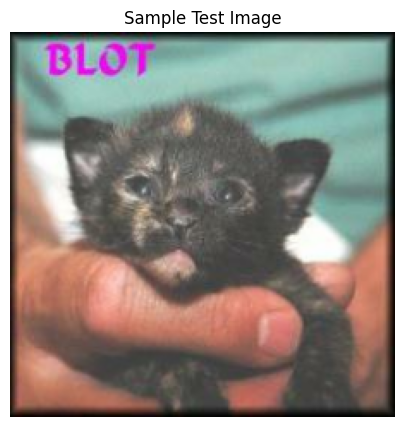

Hugging Face Predictions:
--------------------------------
mink : 80.91 %
weasel : 7.41 %
skunk, polecat, wood pussy : 7.03 %
polecat, fitch, foulmart, foumart, Mustela putorius : 0.62 %
hamster : 0.49 %

ResNet-50 Transfer Learning Prediction:
--------------------------------
Predicted Class : Cat
Confidence      : 60.89 %

Actual Class:
--------------------------------
Cat

Prediction Comparison
--------------------------------
Actual Class       : Cat
Transfer Learning  : Cat
Hugging Face Top Prediction : mink

Observation
--------------------------------
The models produced different predictions.

TASK D COMPLETED SUCCESSFULLY
Student Roll No : 24BAD103


In [8]:
# TASK D: USING HUGGING FACE PRE-TRAINED MODELS
# Student Roll No: 24BAD103

!pip install -q transformers torch pillow

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline

print("Hugging Face libraries installed successfully!")


# Load a pre-trained vision model from Hugging Face

hf_classifier = pipeline(
    "image-classification",
    model="microsoft/resnet-50"
)

print("Hugging Face ResNet-50 model loaded successfully!")


# Select a sample image from the test dataset

sample_batch = next(iter(test_ds))

sample_images, sample_labels = sample_batch

sample_index = 0

image_array = sample_images[sample_index].numpy()

true_label = int(sample_labels[sample_index].numpy())


# Convert image to display format

image_array_uint8 = (image_array * 255).astype(np.uint8)

sample_image = Image.fromarray(image_array_uint8)


# Display sample image

plt.figure(figsize=(5, 5))

plt.imshow(sample_image)

plt.axis("off")

plt.title("Sample Test Image")

plt.show()


# Hugging Face prediction

hf_prediction = hf_classifier(sample_image)

print("Hugging Face Predictions:")
print("--------------------------------")

for prediction in hf_prediction[:5]:

    print(
        prediction["label"],
        ":",
        round(prediction["score"] * 100, 2),
        "%"
    )


# ResNet-50 transfer learning prediction

resnet_input = np.expand_dims(image_array, axis=0)

resnet_prediction = model.predict(
    resnet_input,
    verbose=0
)

resnet_class = np.argmax(resnet_prediction[0])

class_names = ["Cat", "Dog"]

resnet_label = class_names[resnet_class]

resnet_confidence = (
    resnet_prediction[0][resnet_class] * 100
)


print("\nResNet-50 Transfer Learning Prediction:")
print("--------------------------------")
print("Predicted Class :", resnet_label)
print("Confidence      :", round(resnet_confidence, 2), "%")


# Actual class

actual_label = class_names[true_label]

print("\nActual Class:")
print("--------------------------------")
print(actual_label)


# Compare predictions

print("\nPrediction Comparison")
print("--------------------------------")
print("Actual Class       :", actual_label)
print("Transfer Learning  :", resnet_label)
print("Hugging Face Top Prediction :", hf_prediction[0]["label"])


print("\nObservation")
print("--------------------------------")

if resnet_label.lower() in hf_prediction[0]["label"].lower():

    print("Both models produced a compatible prediction.")

else:

    print("The models produced different predictions.")


print("\nTASK D COMPLETED SUCCESSFULLY")
print("Student Roll No :", "24BAD103")